In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

# Upload the file
print("Please upload the Excel file (ai_Chikunguniya.xlsx):")
uploaded = files.upload()

# Read the Excel file
file_name = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[file_name]), sheet_name='Sheet1')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")

# Clean the data - replace 'Null' strings with NaN
df.replace('Null', np.nan, inplace=True)
df.replace('null', np.nan, inplace=True)

# Filter only Chikungunya patients
df_chik = df[df['Disease Type'].str.contains('Chikungunya', case=False, na=False)].copy()
print(f"\nTotal Patients: {len(df)}")
print(f"Chikungunya Patients: {len(df_chik)}")

# Define total for ratio calculations
total_chik = len(df_chik)

Please upload the Excel file (ai_Chikunguniya.xlsx):


Saving ai_Chikunguniya.xlsx to ai_Chikunguniya.xlsx
Dataset Shape: (105, 48)

Column Names:
0: SL
1: Date of on set of symptomes
2: High Fever
3: Headache
4: Muscle Pain
5: Joint Pain
6: Rash
7: Bleeding Menifestations
8: Date of Diagnosis
9: Disease Type
10: Severity Classification
11: Hospitalization status
12: Outcome
13: Age
14: Gender
15: CBC
16: NSI Antigen
17: Dengue IgG (+) and IgM (+)/(-)
18: RT PCR test for Chikungunya
19: Chikongunya IgG and IgM
20: Frequency of Timing
21: Magnitude: Mild/Moderate/Severe
22: Mosquito outbreak
23: Temperature
24: Rainfall/precipitation amount, frequency, intensity
25: Place
26: Proximity to water source (River,lakes, drains)
27: Housing types/ Building materials
28: Drainage system
29: Waste management infrastructure (Garbage collection frequency, presence of open dumps)
30: Waterlogging
31: Household income/poverty levels: (Tk per year)
32: Occupation Type
33: Educational level/Literacy
34: Overcrowding (Person per room)
35: Water storage pr

1. MOSQUITO OUTBREAK ANALYSIS - CHIKUNGUNYA


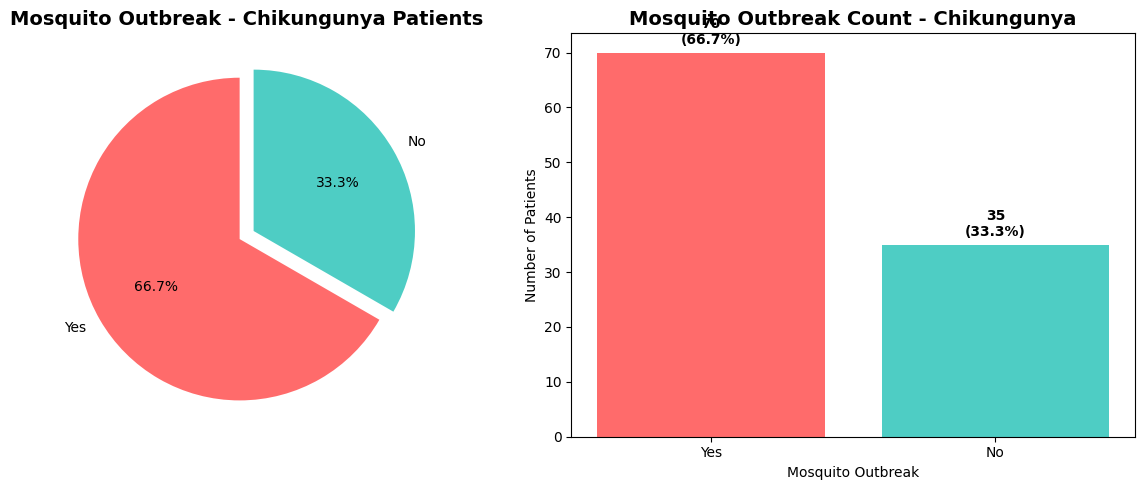


Mosquito Outbreak Ratio for Chikungunya Patients:
Total Chikungunya Patients: 105
  Yes: 70 patients, Ratio: 66.67%
  No: 35 patients, Ratio: 33.33%

  Affected by Mosquito: 70 (66.67%)
  Not Affected/Unknown: 35 (33.33%)


In [ ]:
# =============================================================================
# 1. MOSQUITO OUTBREAK ANALYSIS
# =============================================================================

print("="*60)
print("1. MOSQUITO OUTBREAK ANALYSIS - CHIKUNGUNYA")
print("="*60)

plt.figure(figsize=(12, 5))

# Subplot 1: Mosquito Outbreak for Chikungunya
plt.subplot(1, 2, 1)
mosquito_chik = df_chik['Mosquito outbreak'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#FFE66D']

# Dynamically create explode based on number of categories
explode_values = [0.05] * len(mosquito_chik)

plt.pie(mosquito_chik.values, labels=mosquito_chik.index, autopct='%1.1f%%',
        colors=colors[:len(mosquito_chik)], startangle=90, explode=explode_values)
plt.title('Mosquito Outbreak - Chikungunya Patients', fontsize=14, fontweight='bold')

# Subplot 2: Bar Chart with Ratios
plt.subplot(1, 2, 2)
bars = plt.bar(mosquito_chik.index, mosquito_chik.values, color=colors[:len(mosquito_chik)])
plt.title('Mosquito Outbreak Count - Chikungunya', fontsize=14, fontweight='bold')
plt.xlabel('Mosquito Outbreak')
plt.ylabel('Number of Patients')

# Add value labels and ratios
for bar, value in zip(bars, mosquito_chik.values):
    ratio = (value / total_chik) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{value}\n({ratio:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nMosquito Outbreak Ratio for Chikungunya Patients:")
print(f"Total Chikungunya Patients: {total_chik}")
for index, value in mosquito_chik.items():
    ratio = (value / total_chik) * 100
    print(f"  {index}: {value} patients, Ratio: {ratio:.2f}%")

# Calculate affected vs not affected ratio
if 'Yes' in mosquito_chik.index:
    affected = mosquito_chik.get('Yes', 0)
    not_affected = total_chik - affected
    print(f"\n  Affected by Mosquito: {affected} ({affected/total_chik*100:.2f}%)")
    print(f"  Not Affected/Unknown: {not_affected} ({not_affected/total_chik*100:.2f}%)")


2. TEMPERATURE ANALYSIS - Hot vs Cold Ratio


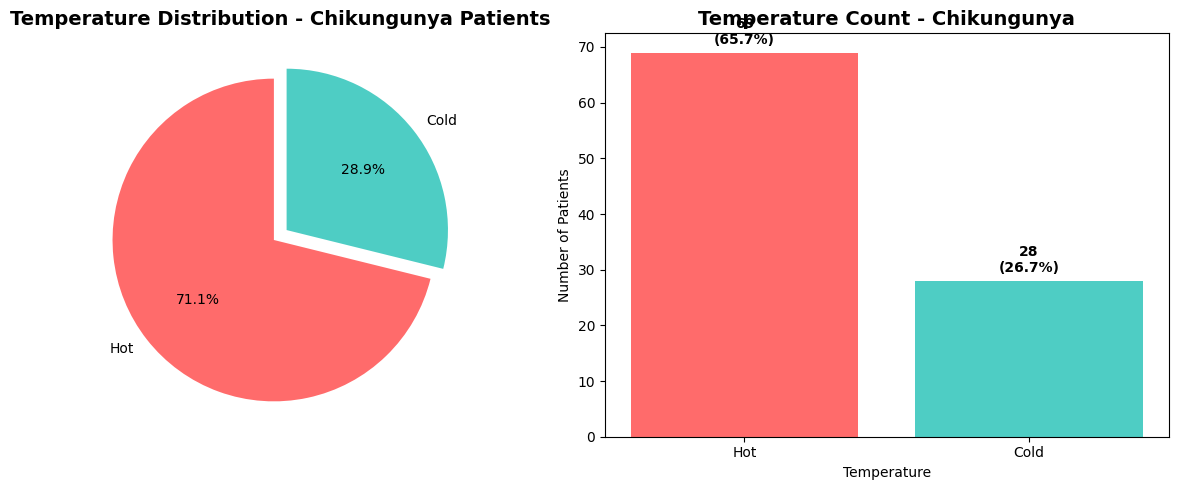


Temperature Ratio for Chikungunya Patients:
  Hot: 69 patients, Ratio: 65.71%
  Cold: 28 patients, Ratio: 26.67%

Hot to Cold Ratio: 2.46:1


In [ ]:
# =============================================================================
# 2. TEMPERATURE ANALYSIS (Hot vs Cold Ratio)
# =============================================================================

print("\n" + "="*60)
print("2. TEMPERATURE ANALYSIS - Hot vs Cold Ratio")
print("="*60)

plt.figure(figsize=(12, 5))

# Subplot 1: Temperature Distribution
plt.subplot(1, 2, 1)
temp_counts = df_chik['Temperature'].value_counts()
colors_temp = ['#FF6B6B', '#4ECDC4', '#FFE66D', '#95E1D3']
explode_temp = [0.05] * len(temp_counts)

plt.pie(temp_counts.values, labels=temp_counts.index, autopct='%1.1f%%',
        colors=colors_temp[:len(temp_counts)], startangle=90, explode=explode_temp)
plt.title('Temperature Distribution - Chikungunya Patients', fontsize=14, fontweight='bold')

# Subplot 2: Bar Chart
plt.subplot(1, 2, 2)
bars = plt.bar(temp_counts.index, temp_counts.values, color=colors_temp[:len(temp_counts)])
plt.title('Temperature Count - Chikungunya', fontsize=14, fontweight='bold')
plt.xlabel('Temperature')
plt.ylabel('Number of Patients')

for bar, value in zip(bars, temp_counts.values):
    ratio = (value / total_chik) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{value}\n({ratio:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTemperature Ratio for Chikungunya Patients:")
for index, value in temp_counts.items():
    ratio = (value / total_chik) * 100
    print(f"  {index}: {value} patients, Ratio: {ratio:.2f}%")

# Hot to Cold Ratio
hot_count = temp_counts.get('Hot', 0)
cold_count = temp_counts.get('Cold', 0)
if hot_count > 0 and cold_count > 0:
    hot_cold_ratio = hot_count / cold_count
    print(f"\nHot to Cold Ratio: {hot_cold_ratio:.2f}:1")
elif hot_count > 0:
    print(f"\nHot: {hot_count}, Cold: {cold_count} - Only Hot temperature recorded")
elif cold_count > 0:
    print(f"\nHot: {hot_count}, Cold: {cold_count} - Only Cold temperature recorded")


3. RAINFALL FREQUENCY ANALYSIS
Using column: Rainfall/precipitation amount, frequency, intensity


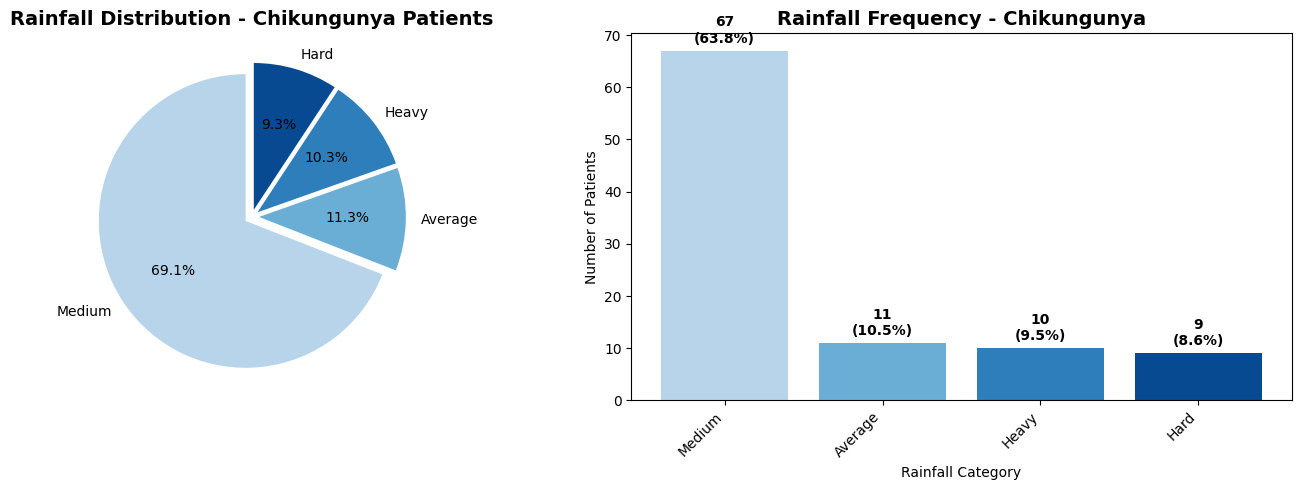


Rainfall Frequency Ratio for Chikungunya Patients:
  Medium: 67 patients, Ratio: 63.81%
  Average: 11 patients, Ratio: 10.48%
  Heavy: 10 patients, Ratio: 9.52%
  Hard: 9 patients, Ratio: 8.57%


In [ ]:
# =============================================================================
# 3. RAINFALL FREQUENCY ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("3. RAINFALL FREQUENCY ANALYSIS")
print("="*60)

# Find the rainfall column
rainfall_col = None
for col in df.columns:
    if 'Rainfall' in col or 'rainfall' in col.lower():
        rainfall_col = col
        break

if rainfall_col is None:
    rainfall_col = 'Rainfall/precipitation amount, frequency, intensity'

print(f"Using column: {rainfall_col}")

plt.figure(figsize=(14, 5))

# Subplot 1: Rainfall Distribution
plt.subplot(1, 2, 1)
rainfall_counts = df_chik[rainfall_col].value_counts()
colors_rain = plt.cm.Blues(np.linspace(0.3, 0.9, len(rainfall_counts)))
explode_rain = [0.05] * len(rainfall_counts)

plt.pie(rainfall_counts.values, labels=rainfall_counts.index, autopct='%1.1f%%',
        colors=colors_rain, startangle=90, explode=explode_rain)
plt.title('Rainfall Distribution - Chikungunya Patients', fontsize=14, fontweight='bold')

# Subplot 2: Bar Chart
plt.subplot(1, 2, 2)
bars = plt.bar(range(len(rainfall_counts)), rainfall_counts.values, color=colors_rain)
plt.xticks(range(len(rainfall_counts)), rainfall_counts.index, rotation=45, ha='right')
plt.title('Rainfall Frequency - Chikungunya', fontsize=14, fontweight='bold')
plt.xlabel('Rainfall Category')
plt.ylabel('Number of Patients')

for i, (bar, value) in enumerate(zip(bars, rainfall_counts.values)):
    ratio = (value / total_chik) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{value}\n({ratio:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRainfall Frequency Ratio for Chikungunya Patients:")
for index, value in rainfall_counts.items():
    ratio = (value / total_chik) * 100
    print(f"  {index}: {value} patients, Ratio: {ratio:.2f}%")


4. HOUSING TYPES / BUILDING MATERIALS ANALYSIS


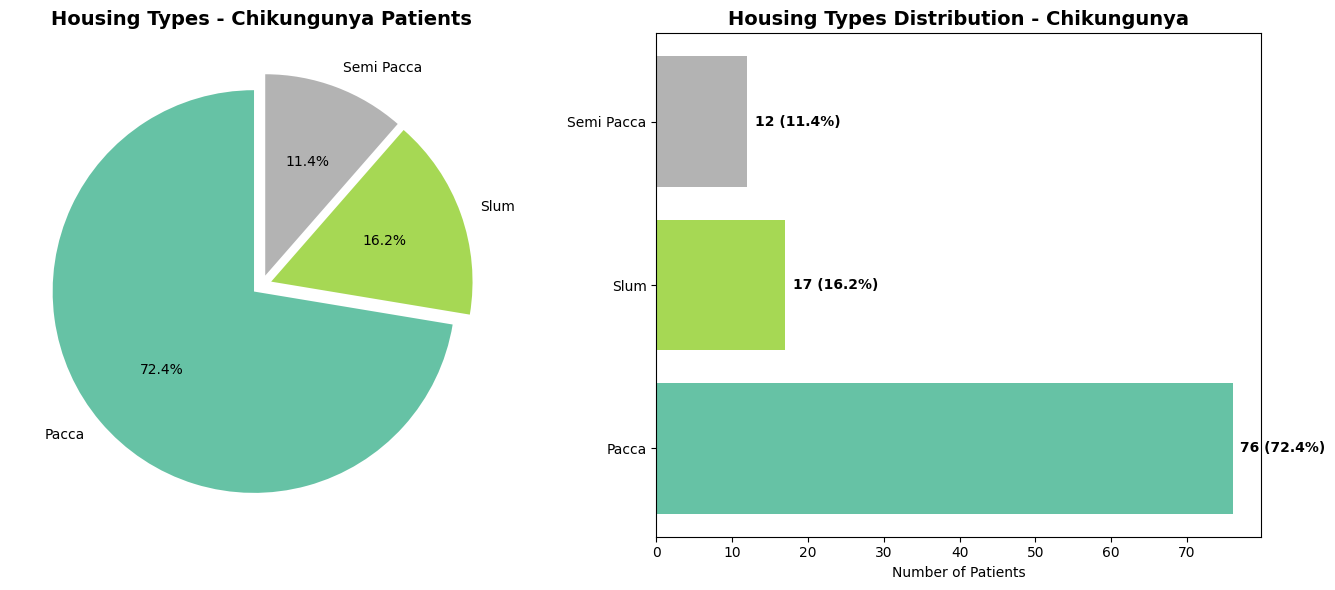


Housing Types Ratio for Chikungunya Patients:
  Pacca: 76 patients, Ratio: 72.38%
  Slum: 17 patients, Ratio: 16.19%
  Semi Pacca: 12 patients, Ratio: 11.43%

Total housing types found: 3
Most common housing type: Pacca (76 patients)


In [ ]:
# =============================================================================
# 4. HOUSING TYPES / BUILDING MATERIALS
# =============================================================================

print("\n" + "="*60)
print("4. HOUSING TYPES / BUILDING MATERIALS ANALYSIS")
print("="*60)

plt.figure(figsize=(14, 6))

# Subplot 1: Housing Types Pie Chart
plt.subplot(1, 2, 1)
housing_counts = df_chik['Housing types/ Building materials'].value_counts()
colors_house = plt.cm.Set2(np.linspace(0, 1, len(housing_counts)))
explode_house = [0.05] * len(housing_counts)

plt.pie(housing_counts.values, labels=housing_counts.index, autopct='%1.1f%%',
        colors=colors_house, startangle=90, explode=explode_house)
plt.title('Housing Types - Chikungunya Patients', fontsize=14, fontweight='bold')

# Subplot 2: Bar Chart
plt.subplot(1, 2, 2)
bars = plt.barh(range(len(housing_counts)), housing_counts.values, color=colors_house)
plt.yticks(range(len(housing_counts)), housing_counts.index)
plt.title('Housing Types Distribution - Chikungunya', fontsize=14, fontweight='bold')
plt.xlabel('Number of Patients')

for bar, value in zip(bars, housing_counts.values):
    ratio = (value / total_chik) * 100
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{value} ({ratio:.1f}%)', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nHousing Types Ratio for Chikungunya Patients:")
for index, value in housing_counts.items():
    ratio = (value / total_chik) * 100
    print(f"  {index}: {value} patients, Ratio: {ratio:.2f}%")

# Additional summary
print(f"\nTotal housing types found: {len(housing_counts)}")
print(f"Most common housing type: {housing_counts.index[0]} ({housing_counts.values[0]} patients)")


5. AGE GROUP ANALYSIS - CHIKUNGUNYA


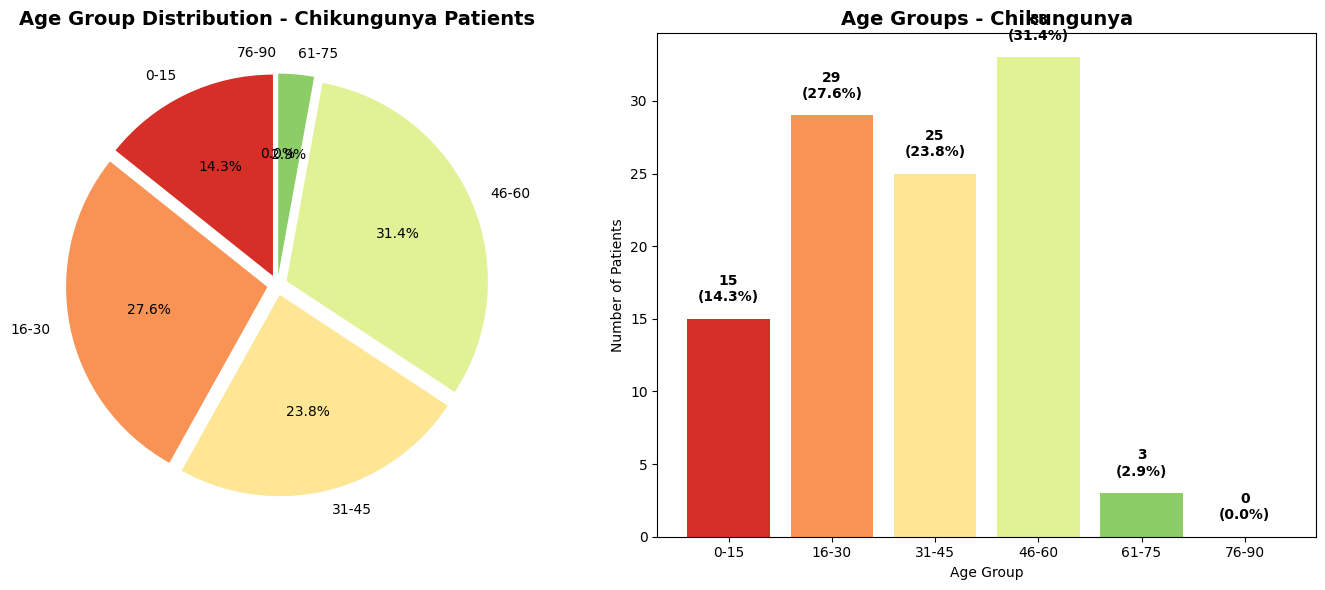


Age Statistics for Chikungunya Patients:
Mean Age: 35.8 years
Median Age: 40.0 years
Min Age: 14 years
Max Age: 68 years

Age Group Ratio:
  0-15 years: 15 patients, Ratio: 14.29%
  16-30 years: 29 patients, Ratio: 27.62%
  31-45 years: 25 patients, Ratio: 23.81%
  46-60 years: 33 patients, Ratio: 31.43%
  61-75 years: 3 patients, Ratio: 2.86%
  76-90 years: 0 patients, Ratio: 0.00%


In [ ]:
# =============================================================================
# 5. AGE GROUP ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("5. AGE GROUP ANALYSIS - CHIKUNGUNYA")
print("="*60)

# Extract numeric age
df_chik['Age_numeric'] = df_chik['Age'].astype(str).str.extract(r'(\d+)').astype(float)

# Create age groups
age_bins = [0, 15, 30, 45, 60, 75, 90]
age_labels = ['0-15', '16-30', '31-45', '46-60', '61-75', '76-90']
df_chik['Age_Group'] = pd.cut(df_chik['Age_numeric'], bins=age_bins, labels=age_labels)

age_group_counts = df_chik['Age_Group'].value_counts().sort_index()

plt.figure(figsize=(14, 6))

# Subplot 1: Age Group Pie Chart
plt.subplot(1, 2, 1)
colors_age = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(age_group_counts)))
explode_age = [0.05] * len(age_group_counts)

plt.pie(age_group_counts.values, labels=age_group_counts.index, autopct='%1.1f%%',
        colors=colors_age, startangle=90, explode=explode_age)
plt.title('Age Group Distribution - Chikungunya Patients', fontsize=14, fontweight='bold')

# Subplot 2: Bar Chart
plt.subplot(1, 2, 2)
bars = plt.bar(range(len(age_group_counts)), age_group_counts.values, color=colors_age)
plt.xticks(range(len(age_group_counts)), age_group_counts.index)
plt.title('Age Groups - Chikungunya', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')

for bar, value in zip(bars, age_group_counts.values):
    ratio = (value / total_chik) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{value}\n({ratio:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nAge Statistics for Chikungunya Patients:")
print(f"Mean Age: {df_chik['Age_numeric'].mean():.1f} years")
print(f"Median Age: {df_chik['Age_numeric'].median():.1f} years")
print(f"Min Age: {df_chik['Age_numeric'].min():.0f} years")
print(f"Max Age: {df_chik['Age_numeric'].max():.0f} years")
print(f"\nAge Group Ratio:")
for index, value in age_group_counts.items():
    ratio = (value / total_chik) * 100
    print(f"  {index} years: {value} patients, Ratio: {ratio:.2f}%")


6. DRAINAGE SYSTEM ANALYSIS


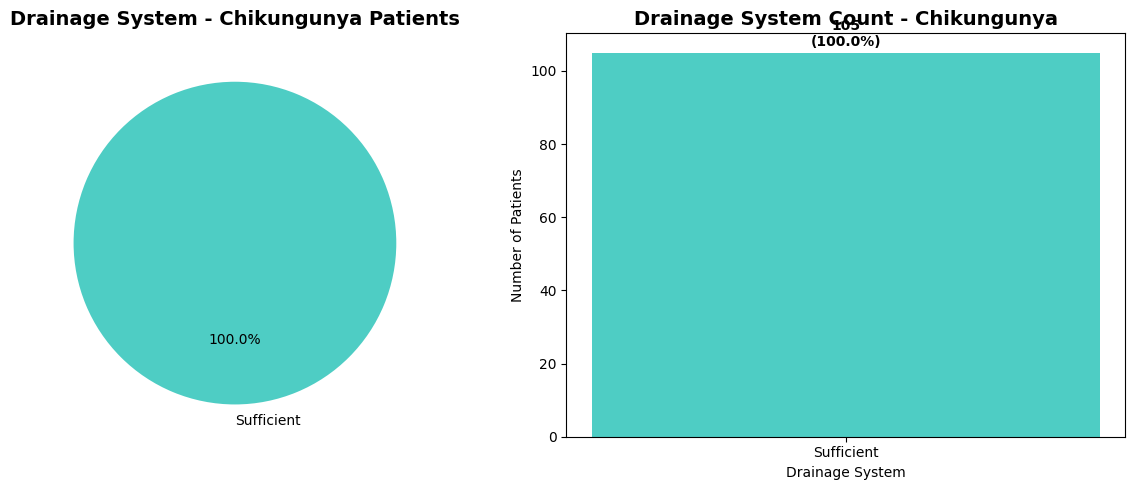


Drainage System Ratio for Chikungunya Patients:
  Sufficient: 105 patients, Ratio: 100.00%


In [ ]:
# =============================================================================
# 6. DRAINAGE SYSTEM ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("6. DRAINAGE SYSTEM ANALYSIS")
print("="*60)

plt.figure(figsize=(12, 5))

# Subplot 1: Drainage System Pie
plt.subplot(1, 2, 1)
drainage_counts = df_chik['Drainage system'].value_counts()
colors_drain = ['#4ECDC4', '#FF6B6B', '#FFE66D']
explode_drain = [0.05] * len(drainage_counts)

plt.pie(drainage_counts.values, labels=drainage_counts.index, autopct='%1.1f%%',
        colors=colors_drain[:len(drainage_counts)], startangle=90, explode=explode_drain)
plt.title('Drainage System - Chikungunya Patients', fontsize=14, fontweight='bold')

# Subplot 2: Bar Chart
plt.subplot(1, 2, 2)
bars = plt.bar(drainage_counts.index, drainage_counts.values,
              color=colors_drain[:len(drainage_counts)])
plt.title('Drainage System Count - Chikungunya', fontsize=14, fontweight='bold')
plt.xlabel('Drainage System')
plt.ylabel('Number of Patients')

for bar, value in zip(bars, drainage_counts.values):
    ratio = (value / total_chik) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{value}\n({ratio:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nDrainage System Ratio for Chikungunya Patients:")
for index, value in drainage_counts.items():
    ratio = (value / total_chik) * 100
    print(f"  {index}: {value} patients, Ratio: {ratio:.2f}%")

# Sufficient to Insufficient Ratio
suff_count = drainage_counts.get('Sufficient', 0)
insuff_count = drainage_counts.get('Insufficient', 0)
if suff_count > 0 and insuff_count > 0:
    ratio_drain = suff_count / insuff_count
    print(f"\nSufficient to Insufficient Ratio: {ratio_drain:.2f}:1")


7. WATERLOGGING ANALYSIS


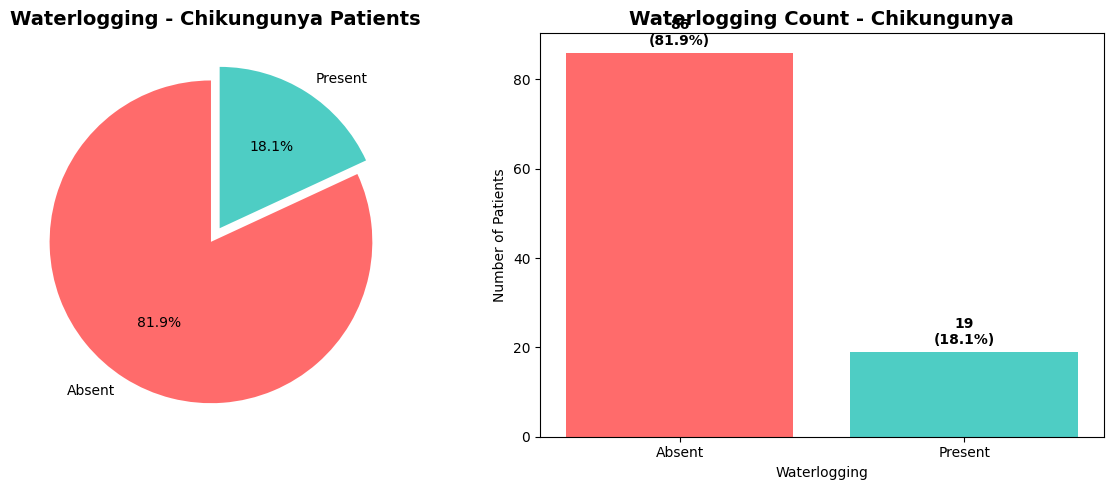


Waterlogging Ratio for Chikungunya Patients:
  Absent: 86 patients, Ratio: 81.90%
  Present: 19 patients, Ratio: 18.10%


In [ ]:
# =============================================================================
# 7. WATERLOGGING ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("7. WATERLOGGING ANALYSIS")
print("="*60)

plt.figure(figsize=(12, 5))

# Subplot 1: Waterlogging Pie
plt.subplot(1, 2, 1)
waterlog_counts = df_chik['Waterlogging'].value_counts()
colors_waterlog = ['#FF6B6B', '#4ECDC4']
explode_waterlog = [0.05] * len(waterlog_counts)

plt.pie(waterlog_counts.values, labels=waterlog_counts.index, autopct='%1.1f%%',
        colors=colors_waterlog[:len(waterlog_counts)], startangle=90, explode=explode_waterlog)
plt.title('Waterlogging - Chikungunya Patients', fontsize=14, fontweight='bold')

# Subplot 2: Bar Chart
plt.subplot(1, 2, 2)
bars = plt.bar(waterlog_counts.index, waterlog_counts.values,
              color=colors_waterlog[:len(waterlog_counts)])
plt.title('Waterlogging Count - Chikungunya', fontsize=14, fontweight='bold')
plt.xlabel('Waterlogging')
plt.ylabel('Number of Patients')

for bar, value in zip(bars, waterlog_counts.values):
    ratio = (value / total_chik) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{value}\n({ratio:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nWaterlogging Ratio for Chikungunya Patients:")
for index, value in waterlog_counts.items():
    ratio = (value / total_chik) * 100
    print(f"  {index}: {value} patients, Ratio: {ratio:.2f}%")

# Yes to No Ratio
yes_wl = waterlog_counts.get('Yes', 0)
no_wl = waterlog_counts.get('No', 0)
if yes_wl > 0 and no_wl > 0:
    ratio_waterlog = yes_wl / no_wl
    print(f"\nYes to No Ratio: {ratio_waterlog:.2f}:1")


8. USE OF VECTOR CONTROL MEASURES ANALYSIS
Using column: Use of vector control measures (bed nets, insecticide sprays, etc)


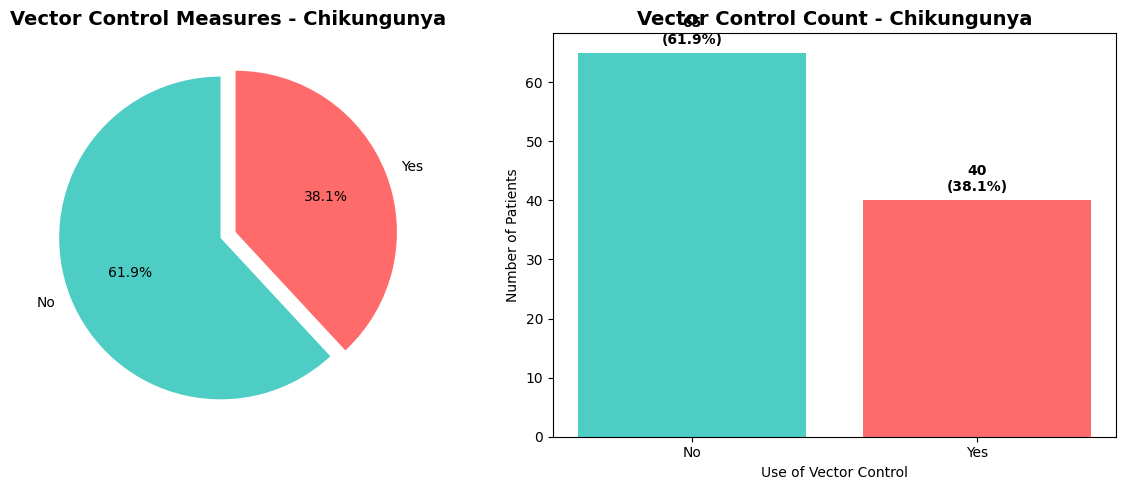


Vector Control Measures Ratio for Chikungunya Patients:
  No: 65 patients, Ratio: 61.90%
  Yes: 40 patients, Ratio: 38.10%

Yes to No Ratio: 0.62:1


In [ ]:
# =============================================================================
# 8. USE OF VECTOR CONTROL MEASURES ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("8. USE OF VECTOR CONTROL MEASURES ANALYSIS")
print("="*60)

# Find the vector control column
vector_col = None
for col in df.columns:
    if 'vector control' in col.lower():
        vector_col = col
        break

if vector_col:
    print(f"Using column: {vector_col}")

    # Convert to Yes/No
    df_chik['Vector_Control'] = df_chik[vector_col].apply(
        lambda x: 'Yes' if str(x).strip().lower() == 'yes' else 'No')

    vector_counts = df_chik['Vector_Control'].value_counts()

    plt.figure(figsize=(12, 5))

    # Subplot 1: Vector Control Pie
    plt.subplot(1, 2, 1)
    colors_vector = ['#4ECDC4', '#FF6B6B']
    explode_vector = [0.05] * len(vector_counts)

    plt.pie(vector_counts.values, labels=vector_counts.index, autopct='%1.1f%%',
            colors=colors_vector[:len(vector_counts)], startangle=90, explode=explode_vector)
    plt.title('Vector Control Measures - Chikungunya', fontsize=14, fontweight='bold')

    # Subplot 2: Bar Chart
    plt.subplot(1, 2, 2)
    bars = plt.bar(vector_counts.index, vector_counts.values,
                  color=colors_vector[:len(vector_counts)])
    plt.title('Vector Control Count - Chikungunya', fontsize=14, fontweight='bold')
    plt.xlabel('Use of Vector Control')
    plt.ylabel('Number of Patients')

    for bar, value in zip(bars, vector_counts.values):
        ratio = (value / total_chik) * 100
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{value}\n({ratio:.1f}%)', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\nVector Control Measures Ratio for Chikungunya Patients:")
    for index, value in vector_counts.items():
        ratio = (value / total_chik) * 100
        print(f"  {index}: {value} patients, Ratio: {ratio:.2f}%")

    yes_vc = vector_counts.get('Yes', 0)
    no_vc = vector_counts.get('No', 0)
    if yes_vc > 0 and no_vc > 0:
        ratio_vector = yes_vc / no_vc
        print(f"\nYes to No Ratio: {ratio_vector:.2f}:1")
else:
    print("Vector Control column not found!")
    print("Available columns:", list(df.columns))


9. ROAD NETWORK ANALYSIS


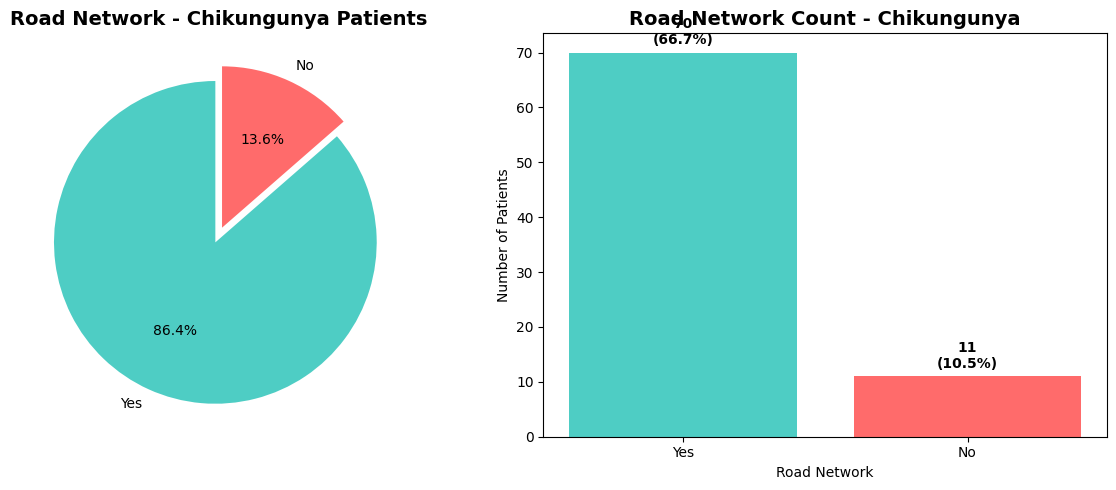


Road Network Ratio for Chikungunya Patients:
  Yes: 70 patients, Ratio: 66.67%
  No: 11 patients, Ratio: 10.48%

Yes to No Ratio: 6.36:1


In [ ]:
# =============================================================================
# 9. ROAD NETWORK ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("9. ROAD NETWORK ANALYSIS")
print("="*60)

plt.figure(figsize=(12, 5))

# Subplot 1: Road Network Pie
plt.subplot(1, 2, 1)
road_counts = df_chik['Road network'].value_counts()
colors_road = ['#4ECDC4', '#FF6B6B']
explode_road = [0.05] * len(road_counts)

plt.pie(road_counts.values, labels=road_counts.index, autopct='%1.1f%%',
        colors=colors_road[:len(road_counts)], startangle=90, explode=explode_road)
plt.title('Road Network - Chikungunya Patients', fontsize=14, fontweight='bold')

# Subplot 2: Bar Chart
plt.subplot(1, 2, 2)
bars = plt.bar(road_counts.index, road_counts.values,
              color=colors_road[:len(road_counts)])
plt.title('Road Network Count - Chikungunya', fontsize=14, fontweight='bold')
plt.xlabel('Road Network')
plt.ylabel('Number of Patients')

for bar, value in zip(bars, road_counts.values):
    ratio = (value / total_chik) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{value}\n({ratio:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nRoad Network Ratio for Chikungunya Patients:")
for index, value in road_counts.items():
    ratio = (value / total_chik) * 100
    print(f"  {index}: {value} patients, Ratio: {ratio:.2f}%")

# Yes to No Ratio
yes_road = road_counts.get('Yes', 0)
no_road = road_counts.get('No', 0)
if yes_road > 0 and no_road > 0:
    ratio_road = yes_road / no_road
    print(f"\nYes to No Ratio: {ratio_road:.2f}:1")


10. WATER NETWORK ANALYSIS


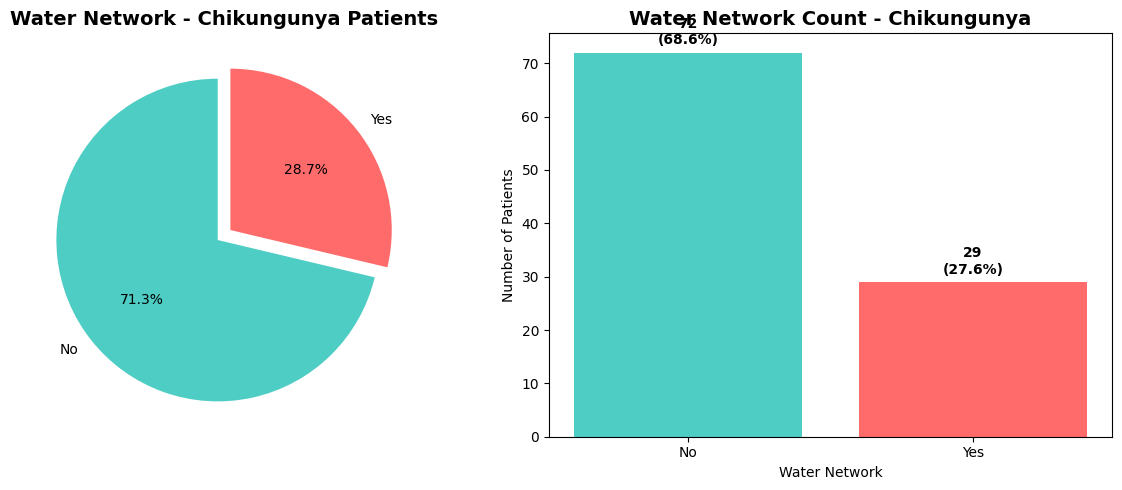


Water Network Ratio for Chikungunya Patients:
  No: 72 patients, Ratio: 68.57%
  Yes: 29 patients, Ratio: 27.62%

Yes to No Ratio: 0.40:1


In [ ]:
# =============================================================================
# 10. WATER NETWORK ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("10. WATER NETWORK ANALYSIS")
print("="*60)

plt.figure(figsize=(12, 5))

# Subplot 1: Water Network Pie
plt.subplot(1, 2, 1)
water_net_counts = df_chik['Water network'].value_counts()
colors_water_net = ['#4ECDC4', '#FF6B6B']
explode_water_net = [0.05] * len(water_net_counts)

plt.pie(water_net_counts.values, labels=water_net_counts.index, autopct='%1.1f%%',
        colors=colors_water_net[:len(water_net_counts)], startangle=90, explode=explode_water_net)
plt.title('Water Network - Chikungunya Patients', fontsize=14, fontweight='bold')

# Subplot 2: Bar Chart
plt.subplot(1, 2, 2)
bars = plt.bar(water_net_counts.index, water_net_counts.values,
              color=colors_water_net[:len(water_net_counts)])
plt.title('Water Network Count - Chikungunya', fontsize=14, fontweight='bold')
plt.xlabel('Water Network')
plt.ylabel('Number of Patients')

for bar, value in zip(bars, water_net_counts.values):
    ratio = (value / total_chik) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{value}\n({ratio:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nWater Network Ratio for Chikungunya Patients:")
for index, value in water_net_counts.items():
    ratio = (value / total_chik) * 100
    print(f"  {index}: {value} patients, Ratio: {ratio:.2f}%")

# Yes to No Ratio
yes_wn = water_net_counts.get('Yes', 0)
no_wn = water_net_counts.get('No', 0)
if yes_wn > 0 and no_wn > 0:
    ratio_water_net = yes_wn / no_wn
    print(f"\nYes to No Ratio: {ratio_water_net:.2f}:1")


11. LONG DISTANCE TRAVEL & IMPORTANT RISK ANALYSIS


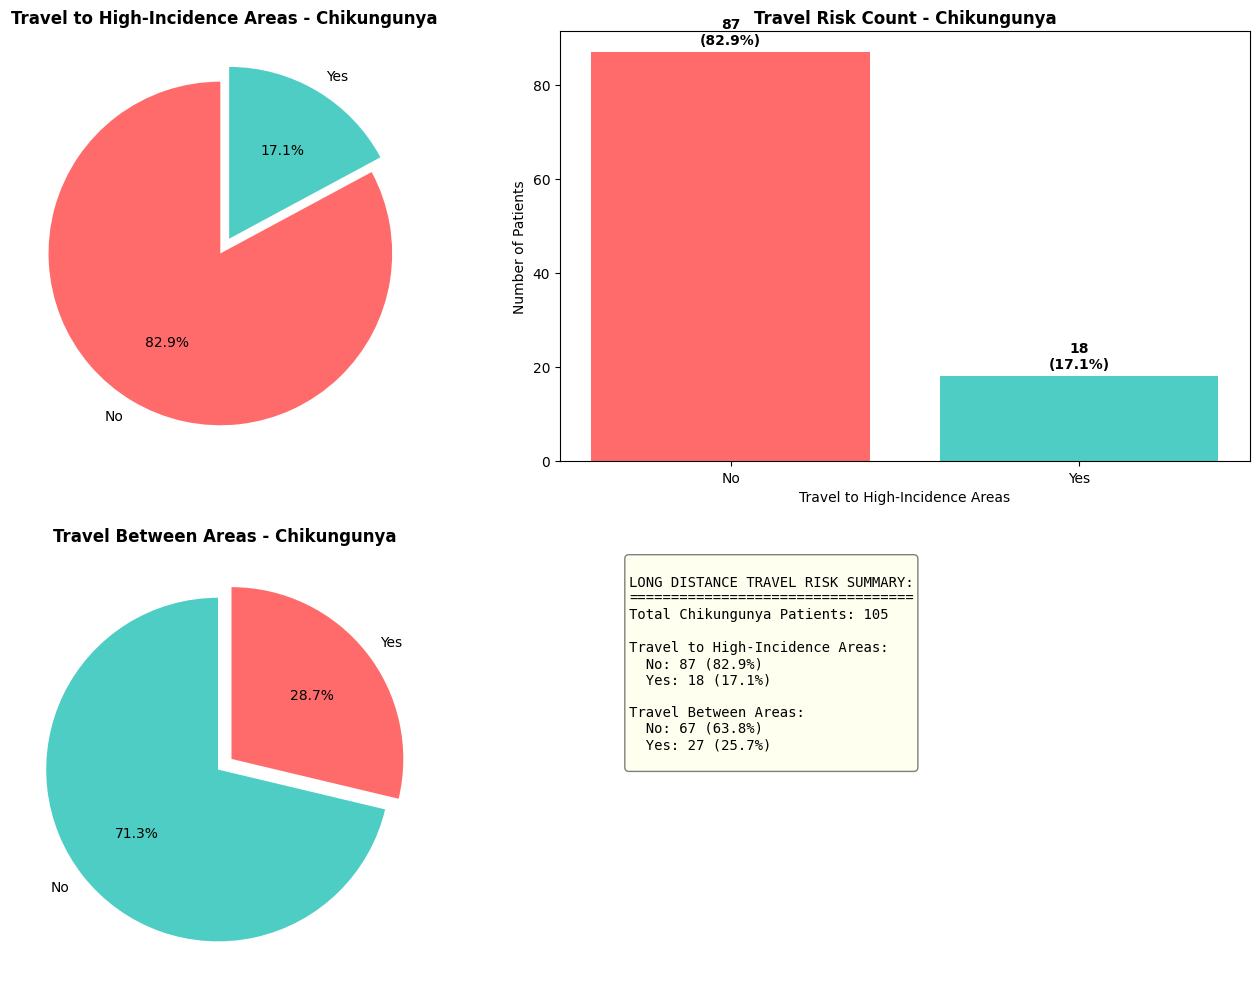


Travel Risk Ratio for Chikungunya Patients:
  Travel to High-Incidence Areas - No: 87 patients, Ratio: 82.86%
  Travel to High-Incidence Areas - Yes: 18 patients, Ratio: 17.14%

Travel Between Areas Ratio:
  No: 67 patients, Ratio: 63.81%
  Yes: 27 patients, Ratio: 25.71%

Travel Risk - Yes to No Ratio: 0.21:1


In [ ]:
# =============================================================================
# 11. LONG DISTANCE TRAVEL & IMPORTANT RISK ANALYSIS
# =============================================================================

print("\n" + "="*60)
print("11. LONG DISTANCE TRAVEL & IMPORTANT RISK ANALYSIS")
print("="*60)

# Find the travel column
travel_col = 'Travel to/from high-incidence areas or endemic regions'

plt.figure(figsize=(14, 10))

# Subplot 1: Travel to High-Incidence Areas Pie
plt.subplot(2, 2, 1)
# Convert to Yes/No
df_chik['Travel_Risk'] = df_chik[travel_col].apply(
    lambda x: 'Yes' if str(x).strip().lower() == 'yes' else 'No')
travel_counts = df_chik['Travel_Risk'].value_counts()
colors_travel = ['#FF6B6B', '#4ECDC4']
explode_travel = [0.05] * len(travel_counts)

plt.pie(travel_counts.values, labels=travel_counts.index, autopct='%1.1f%%',
        colors=colors_travel[:len(travel_counts)], startangle=90, explode=explode_travel)
plt.title('Travel to High-Incidence Areas - Chikungunya', fontsize=12, fontweight='bold')

# Subplot 2: Travel Bar Chart
plt.subplot(2, 2, 2)
bars = plt.bar(travel_counts.index, travel_counts.values,
              color=colors_travel[:len(travel_counts)])
plt.title('Travel Risk Count - Chikungunya', fontsize=12, fontweight='bold')
plt.xlabel('Travel to High-Incidence Areas')
plt.ylabel('Number of Patients')
for bar, value in zip(bars, travel_counts.values):
    ratio = (value / total_chik) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{value}\n({ratio:.1f}%)', ha='center', va='bottom', fontweight='bold')

# Subplot 3: Travel Between Areas Pie
plt.subplot(2, 2, 3)
travel_between_counts = df_chik['Travel between neighborhoods/districts/cities'].value_counts()
colors_between = ['#4ECDC4', '#FF6B6B']
explode_between = [0.05] * len(travel_between_counts)

plt.pie(travel_between_counts.values, labels=travel_between_counts.index, autopct='%1.1f%%',
        colors=colors_between[:len(travel_between_counts)], startangle=90, explode=explode_between)
plt.title('Travel Between Areas - Chikungunya', fontsize=12, fontweight='bold')

# Subplot 4: Summary
plt.subplot(2, 2, 4)
plt.axis('off')
summary_text = f"""
LONG DISTANCE TRAVEL RISK SUMMARY:
==================================
Total Chikungunya Patients: {total_chik}

Travel to High-Incidence Areas:
"""
for index, value in travel_counts.items():
    ratio = (value / total_chik) * 100
    summary_text += f"  {index}: {value} ({ratio:.1f}%)\n"

summary_text += f"\nTravel Between Areas:\n"
for index, value in travel_between_counts.items():
    ratio = (value / total_chik) * 100
    summary_text += f"  {index}: {value} ({ratio:.1f}%)\n"

plt.text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.show()

print("\nTravel Risk Ratio for Chikungunya Patients:")
for index, value in travel_counts.items():
    ratio = (value / total_chik) * 100
    print(f"  Travel to High-Incidence Areas - {index}: {value} patients, Ratio: {ratio:.2f}%")

print("\nTravel Between Areas Ratio:")
for index, value in travel_between_counts.items():
    ratio = (value / total_chik) * 100
    print(f"  {index}: {value} patients, Ratio: {ratio:.2f}%")

# Yes to No Ratios
yes_travel = travel_counts.get('Yes', 0)
no_travel = travel_counts.get('No', 0)
if yes_travel > 0 and no_travel > 0:
    ratio_travel = yes_travel / no_travel
    print(f"\nTravel Risk - Yes to No Ratio: {ratio_travel:.2f}:1")

In [ ]:
# =============================================================================
# COMPREHENSIVE SUMMARY TABLE FOR CHIKUNGUNYA
# =============================================================================

print("\n" + "="*80)
print("COMPREHENSIVE RATIO SUMMARY FOR CHIKUNGUNYA PATIENTS")
print("="*80)

summary_data = []

# 1. Mosquito Outbreak
for index, value in mosquito_chik.items():
    ratio = (value / total_chik) * 100
    summary_data.append(['Mosquito Outbreak', index, value, f'{ratio:.2f}%'])

# 2. Temperature
for index, value in temp_counts.items():
    ratio = (value / total_chik) * 100
    summary_data.append(['Temperature', index, value, f'{ratio:.2f}%'])

# 3. Rainfall
for index, value in rainfall_counts.items():
    ratio = (value / total_chik) * 100
    summary_data.append(['Rainfall', index, value, f'{ratio:.2f}%'])

# 4. Housing Types
for index, value in housing_counts.items():
    ratio = (value / total_chik) * 100
    summary_data.append(['Housing Type', index, value, f'{ratio:.2f}%'])

# 5. Age Groups
for index, value in age_group_counts.items():
    ratio = (value / total_chik) * 100
    summary_data.append(['Age Group', str(index), value, f'{ratio:.2f}%'])

# 6. Drainage System
for index, value in drainage_counts.items():
    ratio = (value / total_chik) * 100
    summary_data.append(['Drainage System', index, value, f'{ratio:.2f}%'])

# 7. Waterlogging
for index, value in waterlog_counts.items():
    ratio = (value / total_chik) * 100
    summary_data.append(['Waterlogging', index, value, f'{ratio:.2f}%'])

# 8. Vector Control
if 'vector_counts' in locals():
    for index, value in vector_counts.items():
        ratio = (value / total_chik) * 100
        summary_data.append(['Vector Control', index, value, f'{ratio:.2f}%'])

# 9. Road Network
for index, value in road_counts.items():
    ratio = (value / total_chik) * 100
    summary_data.append(['Road Network', index, value, f'{ratio:.2f}%'])

# 10. Water Network
for index, value in water_net_counts.items():
    ratio = (value / total_chik) * 100
    summary_data.append(['Water Network', index, value, f'{ratio:.2f}%'])

# 11. Travel Risk
for index, value in travel_counts.items():
    ratio = (value / total_chik) * 100
    summary_data.append(['Travel to High-Incidence', index, value, f'{ratio:.2f}%'])

# Create summary DataFrame
summary_df = pd.DataFrame(summary_data, columns=['Category', 'Value', 'Count', 'Ratio'])
print(summary_df.to_string(index=False))

# Save summary to CSV
summary_df.to_csv('chikungunya_analysis_ratios.csv', index=False)
print("\n\nSummary saved to 'chikungunya_analysis_ratios.csv'")


COMPREHENSIVE RATIO SUMMARY FOR CHIKUNGUNYA PATIENTS
                Category      Value  Count   Ratio
       Mosquito Outbreak        Yes     70  66.67%
       Mosquito Outbreak         No     35  33.33%
             Temperature        Hot     69  65.71%
             Temperature       Cold     28  26.67%
                Rainfall     Medium     67  63.81%
                Rainfall    Average     11  10.48%
                Rainfall      Heavy     10   9.52%
                Rainfall       Hard      9   8.57%
            Housing Type      Pacca     76  72.38%
            Housing Type       Slum     17  16.19%
            Housing Type Semi Pacca     12  11.43%
               Age Group       0-15     15  14.29%
               Age Group      16-30     29  27.62%
               Age Group      31-45     25  23.81%
               Age Group      46-60     33  31.43%
               Age Group      61-75      3   2.86%
               Age Group      76-90      0   0.00%
         Drainage System Suf

In [ ]:
# =============================================================================
# FINAL SUMMARY STATISTICS
# =============================================================================

print("\n" + "="*80)
print("CHIKUNGUNYA ANALYSIS - KEY FINDINGS")
print("="*80)

print(f"""
TOTAL CHIKUNGUNYA PATIENTS: {total_chik}

1. MOSQUITO OUTBREAK:
   - Affected: {mosquito_chik.get('Yes', 0)} ({(mosquito_chik.get('Yes', 0)/total_chik*100):.1f}%)

2. TEMPERATURE:
   - Hot: {temp_counts.get('Hot', 0)} ({(temp_counts.get('Hot', 0)/total_chik*100):.1f}%)
   - Cold: {temp_counts.get('Cold', 0)} ({(temp_counts.get('Cold', 0)/total_chik*100):.1f}%)

3. RAINFALL:
   Most common: {rainfall_counts.index[0]} ({rainfall_counts.values[0]} patients)

4. HOUSING:
   Most common: {housing_counts.index[0]} ({housing_counts.values[0]} patients)

5. AGE:
   Mean: {df_chik['Age_numeric'].mean():.1f} years
   Most affected group: {age_group_counts.index[0]} ({age_group_counts.values[0]} patients)

6. DRAINAGE:
   Sufficient: {drainage_counts.get('Sufficient', 0)}
   Insufficient: {drainage_counts.get('Insufficient', 0)}

7. WATERLOGGING:
   Yes: {waterlog_counts.get('Yes', 0)} ({(waterlog_counts.get('Yes', 0)/total_chik*100):.1f}%)
   No: {waterlog_counts.get('No', 0)} ({(waterlog_counts.get('No', 0)/total_chik*100):.1f}%)

8. VECTOR CONTROL:
   Yes: {vector_counts.get('Yes', 0) if 'vector_counts' in locals() else 'N/A'}
   No: {vector_counts.get('No', 0) if 'vector_counts' in locals() else 'N/A'}

9. ROAD NETWORK:
   Yes: {road_counts.get('Yes', 0)}
   No: {road_counts.get('No', 0)}

10. WATER NETWORK:
    Yes: {water_net_counts.get('Yes', 0)}
    No: {water_net_counts.get('No', 0)}

11. LONG DISTANCE TRAVEL RISK:
    Yes: {travel_counts.get('Yes', 0)} ({(travel_counts.get('Yes', 0)/total_chik*100):.1f}%)
    No: {travel_counts.get('No', 0)} ({(travel_counts.get('No', 0)/total_chik*100):.1f}%)
""")

print("="*80)
print("ANALYSIS COMPLETE!")
print("="*80)


CHIKUNGUNYA ANALYSIS - KEY FINDINGS

TOTAL CHIKUNGUNYA PATIENTS: 105

1. MOSQUITO OUTBREAK:
   - Affected: 70 (66.7%)

2. TEMPERATURE:
   - Hot: 69 (65.7%)
   - Cold: 28 (26.7%)

3. RAINFALL:
   Most common: Medium (67 patients)

4. HOUSING:
   Most common: Pacca (76 patients)

5. AGE:
   Mean: 35.8 years
   Most affected group: 0-15 (15 patients)

6. DRAINAGE:
   Sufficient: 105
   Insufficient: 0

7. WATERLOGGING:
   Yes: 0 (0.0%)
   No: 0 (0.0%)

8. VECTOR CONTROL:
   Yes: 40
   No: 65

9. ROAD NETWORK:
   Yes: 70
   No: 11

10. WATER NETWORK:
    Yes: 29
    No: 72

11. LONG DISTANCE TRAVEL RISK:
    Yes: 18 (17.1%)
    No: 87 (82.9%)

ANALYSIS COMPLETE!
